## ViT on MNIST — Vision Transformer 手写数字识别

### 什么是 Vision Transformer？

ViT 将图片切分为多个小块（patch），像 NLP 中的 token 一样送入 Transformer 编码器，通过**自注意力机制**捕捉全局依赖关系。

### ViT 数据流

```
28×28 图片
   │  切分为 4×4 patches = 7×7 = 49 个 patch
   ▼
Patch Embedding（Conv2d stride=4 投影到 embed_dim=64）
   │
   ▼  加上 class_token + position embedding
[CLS] [P1] [P2] ... [P49]     ← 50 个 token
   │
   ▼  Transformer Encoder × 4 层
   │  每层：自注意力（每个 patch 关注所有 patch）+ 前馈网络
   ▼
取 [CLS] 的输出 → LayerNorm → Linear(64, 10) → 分类结果
```

### ViT vs CNN 的根本差异

| | CNN | ViT |
|------|-----|-----|
| 基本操作 | 卷积（局部感受野） | 自注意力（全局感受野） |
| 归纳偏置 | 平移不变性、局部性（硬编码） | 几乎无归纳偏置（靠数据学） |
| 数据需求 | 小数据集也有效 | 需大量数据才能发挥优势 |
| 第一层感受野 | 3×3 局部 | 全局 |

> 论文: *An Image is Worth 16x16 Words* (Dosovitskiy et al., 2020)
> 注意：MNIST 是小数据集（60K），ViT 不占优势，但作为架构对比非常有学习价值。

## 1. 导入依赖 & 数据加载

ViT 输入格式与 CNN 相同：`(N, 1, 28, 28)` 图像张量。内部通过 Conv2d(stride=patch_size) 自动切分。

In [1]:
# [1.1 导入依赖]
# ViT 将图片切分为 patches → Transformer | 自注意力全局建模 | 小数据集性能可能不如 CNN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

# ==== 中文字体配置 ====
# matplotlib 默认不支持中文，需手动指定支持中文的字体
# 优先级：微软雅黑 > 黑体 > DejaVu Sans（英文回退）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')

设备: cuda


In [2]:
# [1.2 加载 MNIST 数据]
mnist = fetch_openml(
    name="mnist_784", version=1, as_frame=False,
    cache=True, data_home="../data"
)
X = mnist.data.reshape(-1, 28, 28).astype(np.uint8)
y = mnist.target.astype(np.uint8)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# ViT 输入: (N, 1, 28, 28) 图像格式
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1) / 255.0
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1) / 255.0
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# ======== 超参数集中修改区 ========
BATCH_SIZE = 64
# =================================

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

print(f'训练批次数: {len(train_loader)}, 测试批次数: {len(test_loader)}')

训练批次数: 938, 测试批次数: 157


## 2. 理解 Patch Embedding 和自注意力

### Patch Embedding

用 `Conv2d(stride=4)` 一步完成切分+投影：
```
(B, 1, 28, 28) → Conv2d(1→64, kernel=4, stride=4) → (B, 64, 7, 7) → flatten → (B, 49, 64)
```
49 个 patch，每个投影为 64 维向量。

### Class Token

在序列最前方加一个可学习的 `[CLS]` token（类似 BERT），Transformer 后该 token 聚合了全局信息，直接用于分类。

### 自注意力（Self-Attention）的核心

```
每个 patch 计算自己和其他所有 patch 的相似度
  → 相似度越高，权重越大
  → 加权聚合所有 patch 的信息

这让 ViT 第一层就能看到全局关系（CNN 第一层只能看到 3×3）
```

### Pre-LN（LayerNorm 前置）

`norm_first=True` 表示先做 LayerNorm 再做注意力/FFN，比原始 Transformer 的 Post-LN 训练更稳定。

In [3]:
# [2. 定义 ViT 模型]
class PatchEmbedding(nn.Module):
    """
    将图片切分为 patch 并做线性投影

    28×28, patch=4 → 7×7=49 patches，每个投影到 embed_dim
    用 Conv2d(stride=patch_size) 实现，比手动切分更高效
    """
    def __init__(self, img_size=28, patch_size=4, in_channels=1, embed_dim=64):
        super(PatchEmbedding, self).__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 49
        # Conv2d 实现比手动切分更高效
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)              # (B, embed_dim, H/p, W/p) = (B, 64, 7, 7)
        x = x.flatten(2)              # (B, embed_dim, num_patches) = (B, 64, 49)
        x = x.transpose(1, 2)         # (B, num_patches, embed_dim) = (B, 49, 64)
        return x


class ViT(nn.Module):
    """
    轻量 Vision Transformer，为 MNIST 设计

    结构：
        PatchEmbedding(28→7×7 patches, embed_dim=64)
        → Class Token + Position Embedding
        → Transformer Encoder × 4 层（Pre-LN, GELU）
        → LayerNorm → Linear(64, 10)

    可调参数：
        patch_size=4:  28×28 → 7×7 = 49 patches
        embed_dim=64:  每个 patch 投影到 64 维
        depth=4:       4 层 Transformer Encoder
        num_heads=4:   4 头自注意力
    """
    def __init__(self, img_size=28, patch_size=4, in_channels=1,
                 num_classes=10, embed_dim=64, depth=4,
                 num_heads=4, mlp_ratio=2, dropout=0.1):
        super(ViT, self).__init__()

        # 1. Patch Embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # 2. Class Token + Position Embedding（可学习参数）
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        # 3. Transformer Encoder（Pre-LN 更稳定）
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * mlp_ratio,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True           # Pre-LN: 训练更稳定
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth,
                                               enable_nested_tensor=False)

        # 4. LayerNorm + 分类头
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        # 权重初始化
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x):
        B = x.shape[0]

        # Patch Embedding: (B, C, H, W) → (B, num_patches, embed_dim)
        x = self.patch_embed(x)

        # 拼接 class token: (B, 1, embed_dim) + (B, num_patches, embed_dim)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        # 加位置编码 + Dropout
        x = x + self.pos_embed
        x = self.pos_drop(x)

        # Transformer Encoder
        x = self.transformer(x)

        # 取出 class token 对应的输出做分类
        x = self.norm(x[:, 0])
        x = self.head(x)
        return x


# 实例化模型
model = ViT(
    img_size=28, patch_size=4, in_channels=1,
    num_classes=10, embed_dim=64, depth=4,
    num_heads=4, mlp_ratio=2, dropout=0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'总参数量: {total_params:,}')
print(f'可训练参数量: {trainable_params:,}')
print(f'Patch 数量: {model.patch_embed.num_patches} (patch_size=4, 28/4=7 → 7×7)')
print()
print(model)

总参数量: 139,018
可训练参数量: 139,018
Patch 数量: 49 (patch_size=4, 28/4=7 → 7×7)

ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 64, kernel_size=(4, 4), stride=(4, 4))
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Line

## 3. 损失函数与优化器

ViT 原论文推荐 AdamW + CosineAnnealingLR。AdamW 与 Adam 的区别在于 weight decay 的实现方式（解耦权重衰减），对小数据集的 ViT 更友好。

In [4]:
# [3. 损失函数 + 优化器 + 学习率调度器]
# ViT 原论文推荐：AdamW + CosineAnnealingLR

# ======== 超参数集中修改区 ========
LR = 0.001
WEIGHT_DECAY = 0.05      # ViT 论文推荐较强正则
T_MAX = 50               # CosineAnnealing 周期（设为总 epoch 数）
ETA_MIN = 1e-5           # 学习率下限
# =================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=ETA_MIN)

print(f'优化器: AdamW(lr={LR}, weight_decay={WEIGHT_DECAY})')
print(f'调度器: CosineAnnealingLR(T_max={T_MAX}, eta_min={ETA_MIN})')

优化器: AdamW(lr=0.001, weight_decay=0.05)
调度器: CosineAnnealingLR(T_max=50, eta_min=1e-05)


## 4. 训练与评估函数

标准的 PyTorch 训练流程，与 CNN/MLP 完全一致。

In [5]:
# [4. 训练/评估函数]
def train_one_epoch(model, loader, criterion, optimizer, device):
    """训练一个 epoch，返回 (avg_loss, accuracy)"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """评估模型，返回 (avg_loss, accuracy)"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

## 5. 启动训练

训练 50 个 epoch。CosineAnnealingLR 每个 epoch 自动 step。
注意：ViT 在小数据集上可能不如 CNN，这是正常的（缺少 CNN 的归纳偏置）。

In [6]:
# [5. 训练循环]

# ======== 超参数集中修改区 ========
EPOCHS = 50
CHECKPOINT_INTERVAL = 10
SAVE_DIR = '../models/vit'
# =================================

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [],  'test_acc': []
}

best_test_acc = 0.0
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )

    # CosineAnnealingLR 每个 epoch 更新一次
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    # 保存最优模型
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch
        torch.save(model.state_dict(), f'{SAVE_DIR}/best.pth')

    # 定期保存检查点
    if epoch % CHECKPOINT_INTERVAL == 0:
        torch.save(model.state_dict(), f'{SAVE_DIR}/epoch_{epoch}.pth')
        print(f'  [checkpoint] 已保存: vit_epoch_{epoch}.pth')

    # 每 5 个 epoch 或第 1 个 epoch 打印进度
    if epoch % 5 == 0 or epoch == 1:
        print(
            f'Epoch [{epoch:3d}/{EPOCHS}] '
            f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
            f'Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}'
        )

print(f'\n训练完成！最佳测试准确率: {best_test_acc:.4f} (Epoch {best_epoch})')

Epoch [  1/50] Train Loss: 0.9284 | Train Acc: 0.6714 | Test Loss:  0.2644 | Test Acc:  0.9225
Epoch [  5/50] Train Loss: 0.1504 | Train Acc: 0.9530 | Test Loss:  0.1180 | Test Acc:  0.9645
  [checkpoint] 已保存: vit_epoch_10.pth
Epoch [ 10/50] Train Loss: 0.1021 | Train Acc: 0.9689 | Test Loss:  0.0807 | Test Acc:  0.9769
Epoch [ 15/50] Train Loss: 0.0803 | Train Acc: 0.9748 | Test Loss:  0.0720 | Test Acc:  0.9789
  [checkpoint] 已保存: vit_epoch_20.pth
Epoch [ 20/50] Train Loss: 0.0618 | Train Acc: 0.9803 | Test Loss:  0.0516 | Test Acc:  0.9846
Epoch [ 25/50] Train Loss: 0.0488 | Train Acc: 0.9843 | Test Loss:  0.0552 | Test Acc:  0.9838
  [checkpoint] 已保存: vit_epoch_30.pth
Epoch [ 30/50] Train Loss: 0.0382 | Train Acc: 0.9875 | Test Loss:  0.0425 | Test Acc:  0.9874
Epoch [ 35/50] Train Loss: 0.0283 | Train Acc: 0.9909 | Test Loss:  0.0430 | Test Acc:  0.9880
  [checkpoint] 已保存: vit_epoch_40.pth
Epoch [ 40/50] Train Loss: 0.0226 | Train Acc: 0.9926 | Test Loss:  0.0375 | Test Acc:  0.99

## 6. 训练曲线可视化

左侧 Loss 曲线观察收敛情况，右侧 Accuracy 曲线用虚线标出最佳准确率。
ViT 的收敛速度通常比 CNN 慢，因为需要从零学习空间关系。

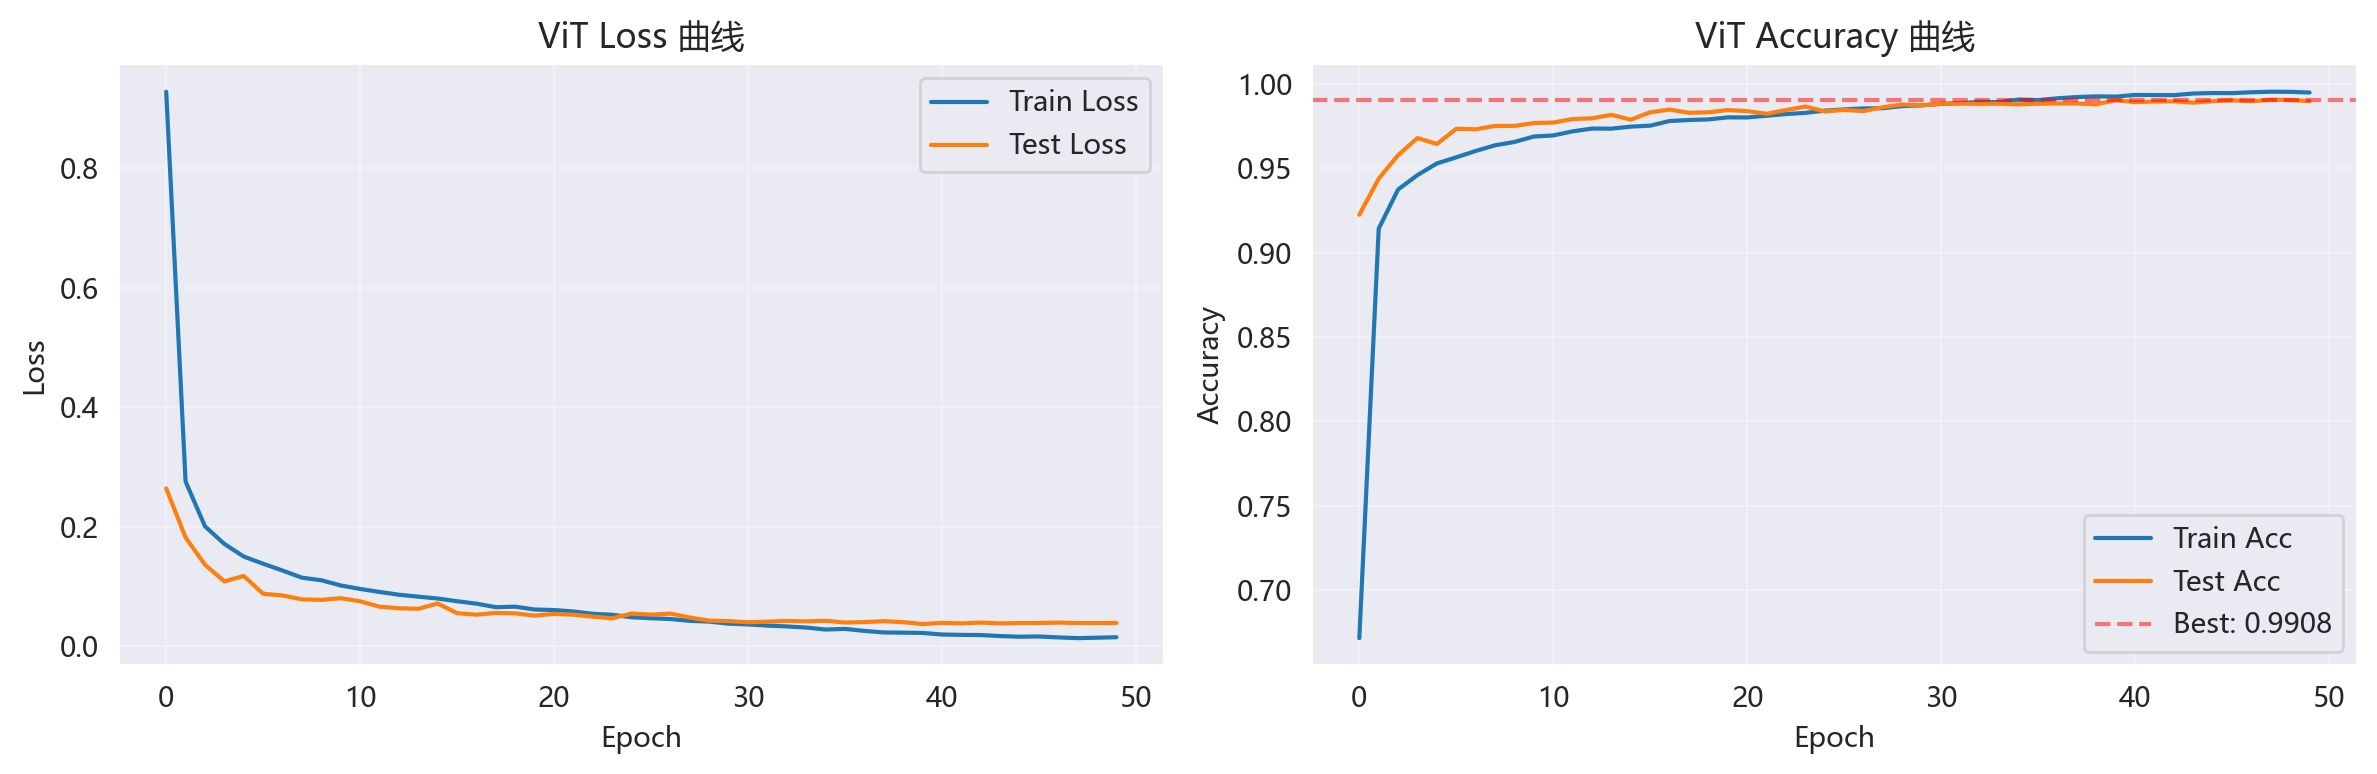

In [7]:
# [6. 训练曲线可视化]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：Loss 曲线
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['test_loss'], label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('ViT Loss 曲线')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：Accuracy 曲线
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['test_acc'], label='Test Acc')
axes[1].axhline(y=best_test_acc, color='r', linestyle='--', alpha=0.5,
                label=f'Best: {best_test_acc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('ViT Accuracy 曲线')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 进一步学习

1. 修改 `patch_size` 观察不同粒度的影响（如 patch_size=7 → 4×4=16 patches）
2. 修改 `depth` 和 `embed_dim` 观察模型容量的影响
3. 阅读原论文 [An Image is Worth 16x16 Words (2020)](https://arxiv.org/abs/2010.11929)